In [6]:
#All the imports
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import norm
from scipy.stats import kurtosis
from scipy.ndimage import maximum_filter, label
import multiprocessing as mp
import os
from scipy.signal import find_peaks

In [14]:
#Function Definitions
def partial_x_2d(f,dx):
    """Compute ∂f/∂x using 2nd-order central differences with periodic BCs."""
    Nx, Ny = f.shape
    df_dx = np.zeros_like(f)
    
    # Central difference in x-direction (axis=0)
    df_dx[1:Nx-1, :] = (f[2:Nx, :] - f[0:Nx-2, :]) / (2 * dx)
    
    # Periodic boundaries (x-direction)
    df_dx[0, :] = (f[1, :] - f[-1, :]) / (2 * dx)
    df_dx[-1, :] = (f[0, :] - f[-2, :]) / (2 * dx)
    
    return df_dx

def partial_y_2d(f,dy):
    """Compute ∂f/∂y using 2nd-order central differences with periodic BCs."""
    Nx, Ny = f.shape
    df_dy = np.zeros_like(f)
    
    # Central difference in y-direction (axis=1)
    df_dy[:, 1:Ny-1] = (f[:, 2:Ny] - f[:, 0:Ny-2]) / (2 * dy)
    
    # Periodic boundaries (y-direction)
    df_dy[:, 0] = (f[:, 1] - f[:, -1]) / (2 * dy)
    df_dy[:, -1] = (f[:, 0] - f[:, -2]) / (2 * dy)
    
    return df_dy

def partial_x_fft(f, dx):
    """
    Calculate ∂f/∂x using FFT on a 2D grid.

    Parameters:
        f (2D np.array): Function values on a 2D grid (shape: Nx × Ny).
        dx (float): Grid spacing in the x-direction.

    Returns:
        df_dx (2D np.array): Partial derivative ∂f/∂x.
    """
    nx, ny = f.shape
    kx = np.fft.fftfreq(nx, d=dx) * 2 * np.pi  # Wavenumbers in x
    kx = kx[:, np.newaxis]                     # Make it 2D for broadcasting

    f_hat = np.fft.fft2(f)
    df_dx_hat = 1j * kx * f_hat
    df_dx = np.fft.ifft2(df_dx_hat).real

    return np.array(df_dx)

def partial_y_fft(f, dy):
    """
    Calculate ∂f/∂y using FFT on a 2D grid.

    Parameters:
        f (2D np.array): Function values on a 2D grid (shape: Nx × Ny).
        dy (float): Grid spacing in the y-direction.

    Returns:
        df_dy (2D np.array): Partial derivative ∂f/∂y.
    """
    nx, ny = f.shape
    ky = np.fft.fftfreq(ny, d=dy) * 2 * np.pi  # Wavenumbers in y
    ky = ky[np.newaxis, :]                     # Make it 2D for broadcasting

    f_hat = np.fft.fft2(f)
    df_dy_hat = 1j * ky * f_hat
    df_dy = np.fft.ifft2(df_dy_hat).real

    return df_dy

def index_of_just_smaller(arr, value):
    arr = np.asarray(arr)
    mask = arr < value
    if not np.any(mask):
        return None  # No smaller value exists
    return np.argmax(np.where(mask, arr, -np.inf))

def compute_radial_spectrum(fld, dx, dy, dtype=float):
    nx, ny = fld.shape

    # Fourier wavenumbers
    kx = np.fft.fftfreq(nx, d=dx) * 2 * np.pi
    ky = np.fft.fftfreq(ny, d=dy) * 2 * np.pi
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    K_perp = np.sqrt(KX**2 + KY**2)

    # Power spectrum density
    ff = np.abs(np.fft.ifft2(fld))**2   # use fft2, not ifft2
    P_flat = ff.ravel()
    K_flat = K_perp.ravel()

    # Radial bins
    dk = kx[1] - kx[0]
    k_bins = np.arange(0, np.max(K_flat) + dk, dk)
    nk = len(k_bins)
    P_k = np.zeros(nk, dtype=dtype)

    # Bin indices (vectorized)
    idx_float = K_flat / dk
    i1 = np.floor(idx_float).astype(int)
    i2 = i1 + 1
    w = idx_float - i1   # weight to upper bin

    # Accumulate into bins
    for i in range(len(K_flat)):
        if i1[i] >= 0 and i2[i] < nk:
            P_k[i1[i]] += P_flat[i] * (1 - w[i])
            P_k[i2[i]] += P_flat[i] * w[i]

    # Pack into recarray
    tags = ['kk', 'sp']
    sps = np.recarray((nk,), dtype=[(t, dtype) for t in tags])
    sps['kk'] = k_bins
    sps['sp'] = P_k / dk

    return sps

In [15]:
# List of simulation directories

dx = 0.0625
dy = 0.0625

In [4]:
times = np.arange(0, 301)   # t = 0 to 300
Jmax = []                   # store max |J| at each time

base_path = "/DATA/DEVESH/ExtremeBetaSimulations/0.0625"

for t in times:
    File_Bx = f"{base_path}/Bx_ApJ_t{t}.h5"
    File_By = f"{base_path}/By_ApJ_t{t}.h5"
    File_Bz = f"{base_path}/Bz_ApJ_t{t}.h5"

    with h5py.File(File_Bx, 'r') as fBx, \
         h5py.File(File_By, 'r') as fBy, \
         h5py.File(File_Bz, 'r') as fBz:

        Bx = fBx['DS1'][:].T
        By = fBy['DS1'][:].T
        Bz = fBz['DS1'][:].T

    Jx =  partial_y_fft(Bz, dx)
    Jy = -partial_x_fft(Bz, dx)
    Jz =  partial_x_fft(By, dx) - partial_y_fft(Bx, dx)

    mod_J = np.sqrt(Jx**2 + Jy**2 + Jz**2)
    Jmax.append(np.max(mod_J))
    print(t)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

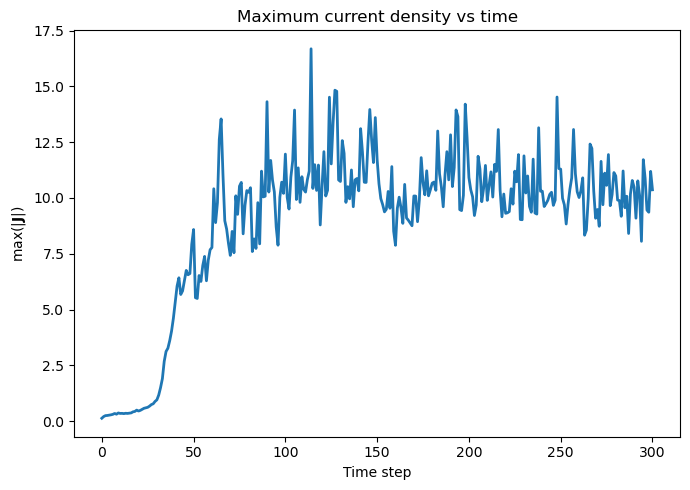

In [33]:
plt.figure(figsize=(7,5))
plt.plot(times, Jmax, lw=2)
plt.xlabel("Time step")
plt.ylabel(r"$\max(|\mathbf{J}|)$")
plt.title("Maximum current density vs time")
plt.tight_layout()
plt.savefig("mod_J_Peak_Reconnection_Time", dpi=300)
plt.show()

In [16]:
from scipy.signal import find_peaks

Jmax = np.array(Jmax)

peaks, props = find_peaks(
    Jmax,
    prominence=0.01 * np.max(Jmax)   # 10% of global max (tune this)
)

first_good_peak = peaks[0]

t_peak = times[first_good_peak]
J_peak = Jmax[first_good_peak]

print(f"First significant peak at t = {t_peak}, J_max = {J_peak:.3e}")

First significant peak at t = 42, J_max = 6.422e+00


In [20]:
# Plotting Power Spectrum at reconnection time

timestep_reconnection = t_peak

File_Bx = f"{base_path}/Bx_ApJ_t{timestep_reconnection}.h5"
File_By = f"{base_path}/By_ApJ_t{timestep_reconnection}.h5"
File_Bz = f"{base_path}/Bz_ApJ_t{timestep_reconnection}.h5"


with h5py.File(File_Bx, 'r') as fBx, \
         h5py.File(File_By, 'r') as fBy, \
         h5py.File(File_Bz, 'r') as fBz:

        Bx = fBx['DS1'][:].T
        By = fBy['DS1'][:].T
        Bz = fBz['DS1'][:].T

data_Jx =  partial_y_fft(Bz, dx)
data_Jy = -partial_x_fft(Bz, dx)
data_Jz =  partial_x_fft(By, dx) - partial_y_fft(Bx, dx)

# Compute radial spectra
spectrum_Jx = compute_radial_spectrum(data_Jx, dx, dy)
spectrum_Jy = compute_radial_spectrum(data_Jy, dx, dy)
spectrum_Jz = compute_radial_spectrum(data_Jz, dx, dy)

# Total perpendicular magnetic spectrum
spectrum_Jp = np.recarray(
    spectrum_Jx.shape, dtype=spectrum_Jx.dtype
)

spectrum_Jp.kk = spectrum_Jx.kk
spectrum_Jp.sp = spectrum_Jx.sp + spectrum_Jy.sp

spectrum_J = np.recarray(spectrum_Jx.shape, dtype=spectrum_Jx.dtype)
spectrum_J.kk = spectrum_Jx.kk
spectrum_J.sp = spectrum_Jx.sp + spectrum_Jy.sp + spectrum_Jz.sp

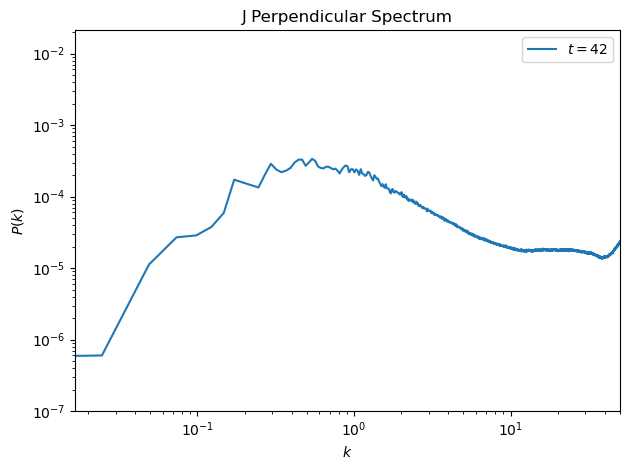

In [30]:
# Plot
plt.loglog(
    spectrum_Jp.kk,
    spectrum_Jp.sp,
    label=fr"$t={t_peak}$"
)

plt.xlabel(r"$k$")
plt.ylabel(r"$P(k)$")
plt.title(r"J Perpendicular Spectrum")
plt.legend()
plt.xlim(None, 50)
plt.ylim(1e-7, None)
plt.tight_layout()
plt.savefig("J_Perpendicular_Spectrum_Reconnection_Time", dpi=300)
plt.show()

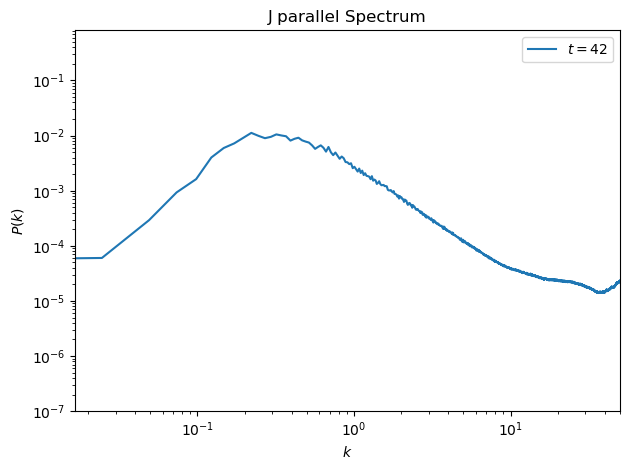

In [31]:
# Plot
plt.loglog(
    spectrum_Jz.kk,
    spectrum_Jz.sp,
    label=fr"$t={t_peak}$"
)

plt.xlabel(r"$k$")
plt.ylabel(r"$P(k)$")
plt.title(r"J parallel Spectrum")
plt.legend()
plt.xlim(None, 50)
plt.ylim(1e-7, None)
plt.tight_layout()
plt.savefig("J_Parallel_Spectrum_Reconnection_Time", dpi=300)
plt.show()

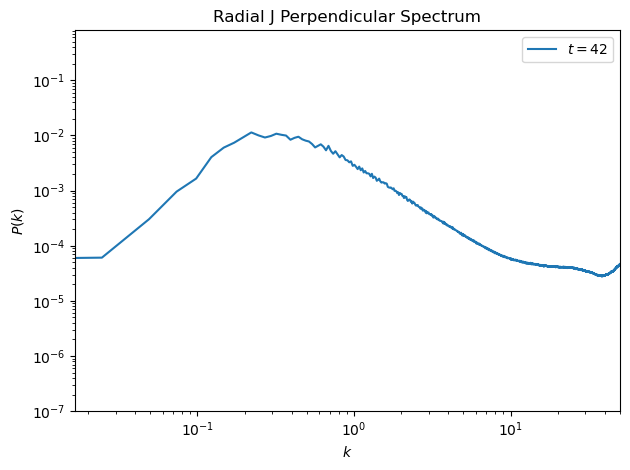

In [32]:
plt.loglog(spectrum_J.kk, spectrum_J.sp, label=fr"$t={t_peak}$")

plt.xlabel(r"$k$")
plt.ylabel(r"$P(k)$")
plt.title(r"Radial J Perpendicular Spectrum")
plt.legend()
plt.xlim(None, 50)
plt.ylim(1e-7, None)
plt.tight_layout()
plt.savefig("J_Spectrum_Reconnection_Time", dpi=300)
plt.show()